# Diabetes Model Bootstrap Comparison

This notebook fits the synthetic glucose data with a log-scale least-squares objective, then compares two bootstrap approaches that respect the multiplicative error used to generate the data:

- Parametric bootstrap with the known lognormal glucose noise scale.
- Log-scale residual bootstrap using fitted log residuals.

The worked example uses `PatientID = 1`. The final section fits all patients once as a sanity check.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares


DATA_PATH = Path("synthetic_patient_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Diabete-Modelling") / "synthetic_patient_data.csv"

PATIENT_ID = 1
N_BOOT = 500
LOG_SIGMA_G = 0.05
BOOT_SEED = 2026

PARAMETER_NAMES = ["RI", "k1", "etaA", "xiA"]
THETA0 = np.array([2.0, 0.004, 0.4, 0.4], dtype=float)
LOWER_BOUNDS = np.array([1.0, 0.001, 0.1, 0.1], dtype=float)
UPPER_BOUNDS = np.array([5.0, 0.010, 0.8, 0.8], dtype=float)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

np.set_printoptions(precision=6, suppress=True)

## Model

These equations match the original notebook's synthetic-data generation model. The fitted parameter vector is `theta = [RI, k1, etaA, xiA]`.

In [2]:
BASE_PARAMS = {
    "Ra": 0.5,
    "Rhep": 0.7,
    "Uii": 0.9,
    "k1": 0.004,
    "RI": 2.0,
    "k2": 0.3,
    "sigma": 8.0,
    "G0": 7.0,
    "n": 2.0,
    "rB": 0.0002,
    "dB": 0.0001,
    "chiA": 0.0005,
    "epsilon": 0.005,
    "alpha": 0.0005,
    "gamma": 0.00005,
    "delta": 0.005,
    "zetaA": 0.3,
    "kappa": 0.00005,
    "theta": 0.00002,
    "kon": 0.02,
    "koff": 0.01,
    "etaA": 0.1,
    "xiA": 0.1,
    "rhoA": 0.3,
    "Gnorm": 5.5,
}

Y0 = np.array([6.0, 15.0, 1.0, 0.9, 0.0, 0.0, 15.0], dtype=float)


def metformin_dose(t):
    return 1.0 if t > 50 else 0.0


def model(t, y, p):
    G, I, B, V, S, A, Ic = y

    G = max(G, 0.0)
    I = max(I, 0.0)
    B = max(B, 1e-6)
    V = min(max(V, 0.0), 1.0)
    S = min(max(S, 0.0), 1.0)
    A = min(max(A, 0.0), 1.0)
    Ic = max(Ic, 0.0)

    dGdt = (
        p["Ra"]
        + p["Rhep"] * (1.0 - p["xiA"] * A)
        - p["Uii"]
        - p["k1"] * (1.0 + p["etaA"] * A) * (I / p["RI"]) * G
    )

    secretion = (
        B
        * p["sigma"]
        * (1.0 / (1.0 + p["rhoA"] * A))
        * (G ** p["n"] / (G ** p["n"] + p["G0"] ** p["n"]))
    )
    dIdt = -p["k2"] * I + secretion

    dBdt = B * p["rB"] * (G / p["Gnorm"] - 1.0) - p["dB"] * B + p["chiA"] * A * B
    dIcdt = p["epsilon"] * (I - Ic)

    glucose_excess = max(G - p["Gnorm"], 0.0)
    damage = p["alpha"] * glucose_excess + p["gamma"] * Ic
    repair = p["delta"] * (1.0 - V) * (1.0 + p["zetaA"] * A)
    dVdt = repair - damage * V

    hazard = p["kappa"] * (1.0 - V) + p["theta"] * (G - p["Gnorm"]) ** 2
    dSdt = hazard * (1.0 - S)

    dAdt = p["kon"] * metformin_dose(t) * (1.0 - A) - p["koff"] * A

    return [dGdt, dIdt, dBdt, dVdt, dSdt, dAdt, dIcdt]


def params_from_theta(theta):
    theta = np.asarray(theta, dtype=float)
    p = BASE_PARAMS.copy()
    p["RI"], p["k1"], p["etaA"], p["xiA"] = theta
    return p


def simulate_full(theta, t_eval):
    t_eval = np.asarray(t_eval, dtype=float)
    sol = solve_ivp(
        model,
        (float(t_eval[0]), float(t_eval[-1])),
        Y0,
        args=(params_from_theta(theta),),
        t_eval=t_eval,
        method="LSODA",
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def simulate_G(theta, t_eval):
    return simulate_full(theta, t_eval).y[0]

## Data

In [3]:
synthetic_df = pd.read_csv(DATA_PATH)
expected_columns = ["PatientID", "Time_days", "G", "I", "B", "V", "S", "A", "Ic"]

assert list(synthetic_df.columns) == expected_columns, synthetic_df.columns.tolist()
assert synthetic_df.shape == (200, 9), synthetic_df.shape

patient_counts = synthetic_df.groupby("PatientID").size()
assert patient_counts.size == 5, patient_counts
assert patient_counts.eq(40).all(), patient_counts

patient_df = (
    synthetic_df.loc[synthetic_df["PatientID"] == PATIENT_ID]
    .sort_values("Time_days")
    .reset_index(drop=True)
)
assert not patient_df.empty, f"No rows found for PatientID={PATIENT_ID}"

t_obs = patient_df["Time_days"].to_numpy(dtype=float)
G_obs = patient_df["G"].to_numpy(dtype=float)
assert np.all(G_obs > 0.0), "Log-scale fitting requires positive glucose observations."

print(f"Loaded {synthetic_df.shape[0]} rows from {DATA_PATH}")
print(patient_counts.rename("n_obs"))
display(patient_df.head())

Loaded 200 rows from synthetic_patient_data.csv
PatientID
1    40
2    40
3    40
4    40
5    40
Name: n_obs, dtype: int64


,PatientID,Time_days,G,I,B,V,S,A,Ic
0,1,0.000000,6.309457,16.553265,1.028535,0.896544,0.000000,0.000000,16.160906
1,1,18.268268,8.065723,14.588321,1.042373,0.871409,0.012748,0.035796,14.242309
2,1,37.267267,8.426657,13.577679,0.907053,0.848826,0.000000,0.119782,16.926108
3,1,55.535536,8.620942,16.697427,1.060794,0.892619,0.017824,0.126834,14.942121
4,1,74.534535,8.548785,16.968805,0.925305,0.842815,0.028821,0.260976,14.886399


## Log-Scale Fit

The synthetic glucose data was generated with multiplicative lognormal noise, so the fitting residual is computed on the log scale.

In [4]:
def log_residuals(theta, t_eval, G_target):
    try:
        G_pred = simulate_G(theta, t_eval)
    except RuntimeError:
        return np.full_like(G_target, 1e6, dtype=float)

    if not np.all(np.isfinite(G_pred)) or np.any(G_pred <= 0.0):
        return np.full_like(G_target, 1e6, dtype=float)

    return np.log(G_target) - np.log(G_pred)


def fit_glucose_logscale(t_obs, G_obs, theta0=THETA0):
    return least_squares(
        lambda theta: log_residuals(theta, t_obs, G_obs),
        x0=np.asarray(theta0, dtype=float),
        bounds=(LOWER_BOUNDS, UPPER_BOUNDS),
        max_nfev=300,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
    )


fit_result = fit_glucose_logscale(t_obs, G_obs)
theta_hat = fit_result.x
G_fit = simulate_G(theta_hat, t_obs)

assert fit_result.success, fit_result.message
assert np.all(theta_hat >= LOWER_BOUNDS) and np.all(theta_hat <= UPPER_BOUNDS)

rmse = np.sqrt(np.mean((G_obs - G_fit) ** 2))
log_rmse = np.sqrt(np.mean(log_residuals(theta_hat, t_obs, G_obs) ** 2))

fit_summary = pd.DataFrame(
    {
        "parameter": PARAMETER_NAMES,
        "estimate": theta_hat,
        "lower_bound": LOWER_BOUNDS,
        "upper_bound": UPPER_BOUNDS,
        "at_lower_bound": np.isclose(theta_hat, LOWER_BOUNDS),
        "at_upper_bound": np.isclose(theta_hat, UPPER_BOUNDS),
    }
)

print(f"Optimizer message: {fit_result.message}")
print(f"RMSE: {rmse:.4f} mmol/L")
print(f"log-RMSE: {log_rmse:.4f}")
display(fit_summary)

Optimizer message: `xtol` termination condition is satisfied.
RMSE: 0.4659 mmol/L
log-RMSE: 0.0576


,parameter,estimate,lower_bound,upper_bound,at_lower_bound,at_upper_bound
0,RI,2.308095,1.000,5.00,False,False
1,k1,0.004348,0.001,0.01,False,False
2,etaA,0.125219,0.100,0.80,False,False
3,xiA,0.137943,0.100,0.80,False,False


## Bootstrap Helpers

In [5]:
def summarize_bootstrap(samples):
    samples = np.asarray(samples, dtype=float)
    valid = np.all(np.isfinite(samples), axis=1)
    valid_samples = samples[valid]
    if valid_samples.size == 0:
        raise ValueError("No valid bootstrap samples were produced.")

    q = np.percentile(valid_samples, [2.5, 50.0, 97.5], axis=0)
    summary = pd.DataFrame(
        {
            "parameter": PARAMETER_NAMES,
            "median": q[1],
            "ci_lower": q[0],
            "ci_upper": q[2],
            "n_valid": int(valid.sum()),
        }
    )
    assert np.all(np.isfinite(summary[["median", "ci_lower", "ci_upper"]].to_numpy()))
    assert (summary["ci_upper"] >= summary["ci_lower"]).all()
    return summary


def _fit_bootstrap_sample(t_obs, G_boot, theta_start):
    result = fit_glucose_logscale(t_obs, G_boot, theta0=theta_start)
    if result.success and np.all(np.isfinite(result.x)):
        return result.x
    return np.full(len(PARAMETER_NAMES), np.nan)


def bootstrap_parametric(theta_hat, t_obs, n_boot=N_BOOT):
    local_rng = np.random.default_rng(BOOT_SEED)
    G_base = simulate_G(theta_hat, t_obs)
    samples = np.full((n_boot, len(PARAMETER_NAMES)), np.nan)

    for i in range(n_boot):
        G_boot = G_base * local_rng.lognormal(
            mean=0.0,
            sigma=LOG_SIGMA_G,
            size=len(G_base),
        )
        assert np.all(G_boot > 0.0)
        samples[i] = _fit_bootstrap_sample(t_obs, G_boot, theta_hat)

    return samples


def bootstrap_log_residual(theta_hat, t_obs, G_obs, n_boot=N_BOOT):
    local_rng = np.random.default_rng(BOOT_SEED + 1)
    G_base = simulate_G(theta_hat, t_obs)
    residuals = np.log(G_obs) - np.log(G_base)
    e_centered = residuals - residuals.mean()

    samples = np.full((n_boot, len(PARAMETER_NAMES)), np.nan)
    for i in range(n_boot):
        resampled_e = local_rng.choice(e_centered, size=len(e_centered), replace=True)
        G_boot = G_base * np.exp(resampled_e)
        assert np.all(G_boot > 0.0)
        samples[i] = _fit_bootstrap_sample(t_obs, G_boot, theta_hat)

    return samples

## Run Both Bootstrap Methods

In [6]:
parametric_samples = bootstrap_parametric(theta_hat, t_obs, n_boot=N_BOOT)
log_residual_samples = bootstrap_log_residual(theta_hat, t_obs, G_obs, n_boot=N_BOOT)

assert parametric_samples.shape == (N_BOOT, 4), parametric_samples.shape
assert log_residual_samples.shape == (N_BOOT, 4), log_residual_samples.shape

parametric_summary = summarize_bootstrap(parametric_samples)
parametric_summary.insert(0, "method", "parametric")

log_residual_summary = summarize_bootstrap(log_residual_samples)
log_residual_summary.insert(0, "method", "log_residual")

bootstrap_summary = pd.concat(
    [parametric_summary, log_residual_summary],
    ignore_index=True,
)
bootstrap_summary = bootstrap_summary.merge(fit_summary[["parameter", "estimate"]], on="parameter")
bootstrap_summary = bootstrap_summary[
    ["method", "parameter", "estimate", "median", "ci_lower", "ci_upper", "n_valid"]
]

display(bootstrap_summary)

,method,parameter,estimate,median,ci_lower,ci_upper,n_valid
0,parametric,RI,2.308095,2.336906,1.827723,3.624227,500
1,parametric,k1,0.004348,0.004348,0.003605,0.006765,500
2,parametric,etaA,0.125219,0.124187,0.100000,0.369089,500
3,parametric,xiA,0.137943,0.132751,0.100000,0.186825,500
4,log_residual,RI,2.308095,2.351627,1.692164,3.085365,500
5,log_residual,k1,0.004348,0.004346,0.003357,0.005992,500
6,log_residual,etaA,0.125219,0.124252,0.100000,0.407615,500
7,log_residual,xiA,0.137943,0.131533,0.100000,0.193033,500


## Fit Curves and Bootstrap Confidence Bands

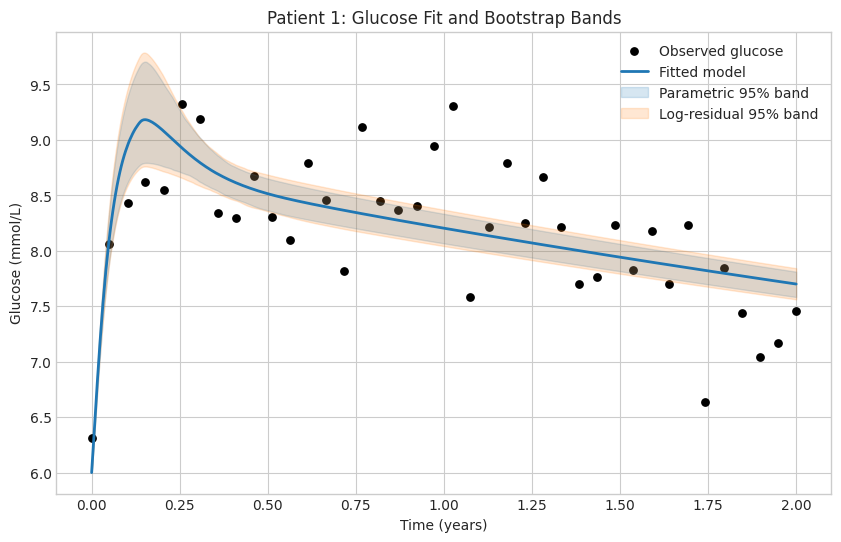

In [7]:
def bootstrap_prediction_band(samples, t_plot):
    valid = np.all(np.isfinite(samples), axis=1)
    trajectories = np.array([simulate_G(theta, t_plot) for theta in samples[valid]])
    assert trajectories.shape[0] > 0
    return np.percentile(trajectories, [2.5, 97.5], axis=0)


t_plot = np.linspace(t_obs.min(), t_obs.max(), 500)
G_plot_fit = simulate_G(theta_hat, t_plot)
parametric_band = bootstrap_prediction_band(parametric_samples, t_plot)
log_residual_band = bootstrap_prediction_band(log_residual_samples, t_plot)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(t_obs / 365.0, G_obs, color="black", s=28, label="Observed glucose")
ax.plot(t_plot / 365.0, G_plot_fit, color="tab:blue", linewidth=2, label="Fitted model")
ax.fill_between(
    t_plot / 365.0,
    parametric_band[0],
    parametric_band[1],
    color="tab:blue",
    alpha=0.18,
    label="Parametric 95% band",
)
ax.fill_between(
    t_plot / 365.0,
    log_residual_band[0],
    log_residual_band[1],
    color="tab:orange",
    alpha=0.18,
    label="Log-residual 95% band",
)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Glucose (mmol/L)")
ax.set_title(f"Patient {PATIENT_ID}: Glucose Fit and Bootstrap Bands")
ax.legend()
plt.show()

## Diagnostics

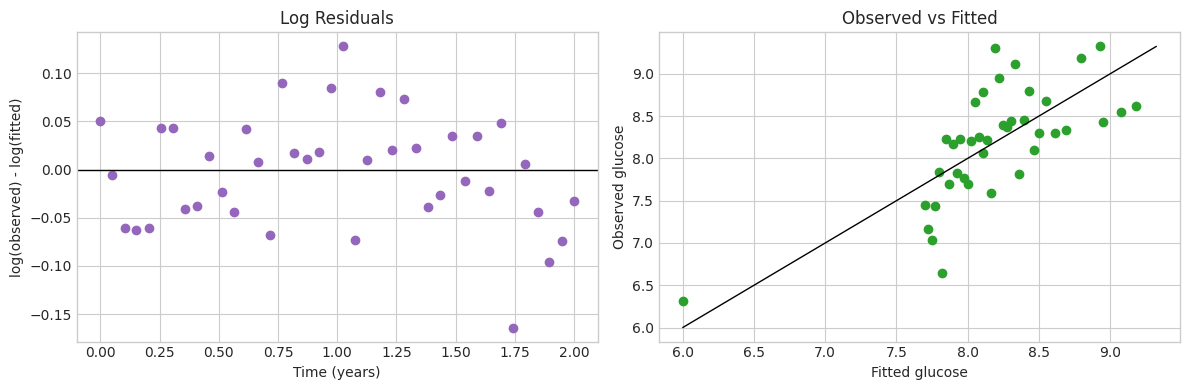

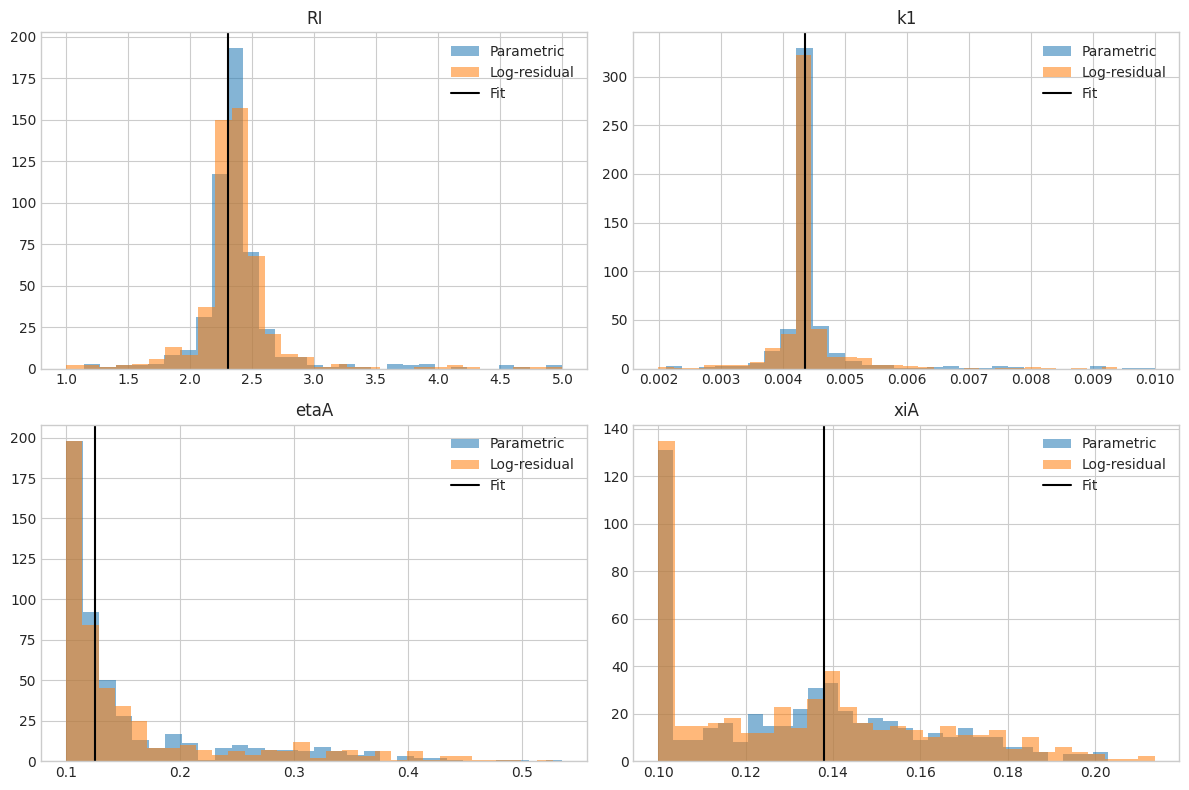

In [8]:
log_fit_residuals = np.log(G_obs) - np.log(G_fit)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].scatter(t_obs / 365.0, log_fit_residuals, color="tab:purple")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("log(observed) - log(fitted)")
axes[0].set_title("Log Residuals")

axes[1].scatter(G_fit, G_obs, color="tab:green")
min_g = min(G_fit.min(), G_obs.min())
max_g = max(G_fit.max(), G_obs.max())
axes[1].plot([min_g, max_g], [min_g, max_g], color="black", linewidth=1)
axes[1].set_xlabel("Fitted glucose")
axes[1].set_ylabel("Observed glucose")
axes[1].set_title("Observed vs Fitted")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name, j in zip(axes.ravel(), PARAMETER_NAMES, range(len(PARAMETER_NAMES))):
    ax.hist(parametric_samples[:, j], bins=30, alpha=0.55, label="Parametric")
    ax.hist(log_residual_samples[:, j], bins=30, alpha=0.55, label="Log-residual")
    ax.axvline(theta_hat[j], color="black", linewidth=1.5, label="Fit")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

## All-Patient Sanity Check

This fits each patient once without bootstrapping, so the notebook can quickly show whether the fitting workflow behaves consistently across the synthetic dataset.

In [9]:
patient_fit_rows = []

for pid, df_pid in synthetic_df.groupby("PatientID"):
    df_pid = df_pid.sort_values("Time_days")
    t_pid = df_pid["Time_days"].to_numpy(dtype=float)
    G_pid = df_pid["G"].to_numpy(dtype=float)
    assert np.all(G_pid > 0.0), f"Patient {pid} has non-positive glucose values."

    result = fit_glucose_logscale(t_pid, G_pid)
    theta_pid = result.x
    G_pid_fit = simulate_G(theta_pid, t_pid)

    row = {
        "PatientID": pid,
        "success": result.success,
        "RMSE": np.sqrt(np.mean((G_pid - G_pid_fit) ** 2)),
        "log_RMSE": np.sqrt(np.mean(log_residuals(theta_pid, t_pid, G_pid) ** 2)),
    }
    row.update(dict(zip(PARAMETER_NAMES, theta_pid)))
    patient_fit_rows.append(row)

patient_fit_summary = pd.DataFrame(patient_fit_rows)
display(patient_fit_summary)

,PatientID,success,RMSE,log_RMSE,RI,k1,etaA,xiA
0,1,True,0.465884,0.057613,2.308095,0.004348,0.125219,0.137943
1,2,True,0.441707,0.049484,2.106591,0.003322,0.143440,0.131214
2,3,True,0.348216,0.042660,2.487747,0.004955,0.164568,0.100049
3,4,True,0.394551,0.049479,1.982694,0.004249,0.115764,0.100115
4,5,True,0.362912,0.044096,2.249768,0.004495,0.100000,0.100000
